# Partial Dependence Plot: EPS vs Analysts' Forecasts

This notebook reproduces the figure "EPS as a non-Linear function of analysts' forecasts" using a Random Forest model. We analyze the relationship between Realized EPS and Analysts' Forecasts.

In [1]:
import sys
from pathlib import Path

# notebook 在 notebooks/ 下，src/ 在上一级
sys.path.insert(0, str(Path("../src").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import partial_dependence
from sklearn import preprocessing
from scipy.stats.mstats import winsorize
from functions import read_merge_prepare_data

%matplotlib inline

## 1. Load Data
We load the macro data and the processed dataset for the chosen period (e.g., A1, Q1). The figure description mentions "one-quarter-ahead realized EPS", which corresponds to `Q1`. However, we can easily switch between periods.

In [2]:
# Load Macro Data
macro_file_path = "../_data/processed_data/macro_data.csv"
Macro_Data = pd.read_csv(macro_file_path)

# Choose period (e.g., 'A1' or 'Q1' based on what you want to visualize)
forecast_period = 'Q1'

# Load and Prepare the Dataset
df = read_merge_prepare_data(forecast_period, Macro_Data, data_dir=Path("../_data"))

print(f"Data Loaded: {len(df)} rows")
df.head()

Q1 Missing Values:
price              17
ret                19
capei           41209
be              41209
bm              41209
                ...  
mktcap          41209
ptb             41209
peg_trailing    41209
divyield        41209
ffi49           41209
Length: 72, dtype: int64
Data Loaded: 887766 rows


,permno,price,ret,meanest,numest,adj_actual,adj_past_eps,capei,be,bm,...,mktcap,ptb,peg_trailing,divyield,ffi49,GDP_log_return,Cons_log_return,IPT_log_return,Unempl,Date
0,63386,11.75,-0.020833,0.35,1.0,0.3500,0.1100,19.871881,37.578,0.228598,...,90.65000,2.412316,0.080192,0.023063,34.0,0.009618,0.009617,0.002404,7.3,1985-02
36,62682,21.00,-0.011765,0.23,1.0,0.2752,0.1664,20.215607,84.282,0.682454,...,115.63125,1.371957,2.807512,0.022857,42.0,0.002225,-0.000744,-0.011470,7.3,1985-03
37,35051,37.00,0.000000,0.10,1.0,0.0800,0.0700,27.878042,156.685,0.233269,...,689.87700,4.402955,3.173548,0.012549,21.0,0.002225,-0.000744,-0.011470,7.3,1985-03
38,55976,45.25,0.008357,0.00,3.0,0.0039,0.0079,56.462495,902.158,0.152798,...,6380.10100,7.072044,0.438309,0.004659,43.0,0.002225,-0.000744,-0.011470,7.3,1985-03
40,13777,18.00,0.000000,0.06,1.0,0.0978,0.0790,14.874196,28.160,0.464975,...,46.87500,1.664595,0.508065,0.021622,34.0,0.002225,-0.000744,-0.011470,7.3,1985-03


In [3]:
# ==========================================
# 1. 数据预处理 (加入 Winsorization)
# ==========================================

# 复制数据以防修改原件
X = df.drop(columns=['adj_actual', 'Date', 'permno', 'numest']).copy()
y = df['adj_actual'].copy()

# 论文脚注15: "winsorize the forecasting variables at the 1% level"
# 对每一列特征进行 1% 的双边缩尾处理
for col in X.columns:
    X[col] = winsorize(X[col], limits=[0.01, 0.01])

# 论文: "and standardize them"
scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
# 将 numpy array 转回 DataFrame 以便保留列名，这对 PDP 很重要
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

meanest_idx = X.columns.get_loc('meanest')
print(f"'meanest' feature is at index: {meanest_idx}")

# ==========================================
# 2. 模型训练 (调整超参数以匹配 Table 1)
# ==========================================

rf_model = RandomForestRegressor(
    n_estimators=2000,
    max_depth=7,
    min_samples_leaf=1,
    max_samples=0.01,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Training Random Forest with Paper Parameters...")
rf_model.fit(X_scaled, y)
print("Training Complete.")

'meanest' feature is at index: 2
Training Random Forest with Paper Parameters...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done 1230 tasks      | elapsed:    9.0s
[Parallel(n_jobs=-1)]: Done 1780 tasks      | elapsed:   13.4s


Training Complete.


[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:   15.3s finished


Calculating Partial Dependence...


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.2s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    1.0s
[Parallel(n_jobs=10)]: Done 430 tasks      | elapsed:    2.4s
[Parallel(n_jobs=10)]: Done 780 tasks      | elapsed:    4.5s
[Parallel(n_jobs=10)]: Done 1230 tasks      | elapsed:    7.2s
[Parallel(n_jobs=10)]: Done 1780 tasks      | elapsed:   10.7s
[Parallel(n_jobs=10)]: Done 2000 out of 2000 | elapsed:   12.3s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.2s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    1.1s
[Parallel(n_jobs=10)]: Done 430 tasks      | elapsed:    2.5s
[Parallel(n_jobs=10)]: Done 780 tasks      | elapsed:    4.5s
[Parallel(n_jobs=10)]: Done 1230 tasks      | elapsed:    7.2s
[Parallel(n_jobs=10)]: Done 1780 tasks      | elapsed:   10.4s
[Parallel(n_job

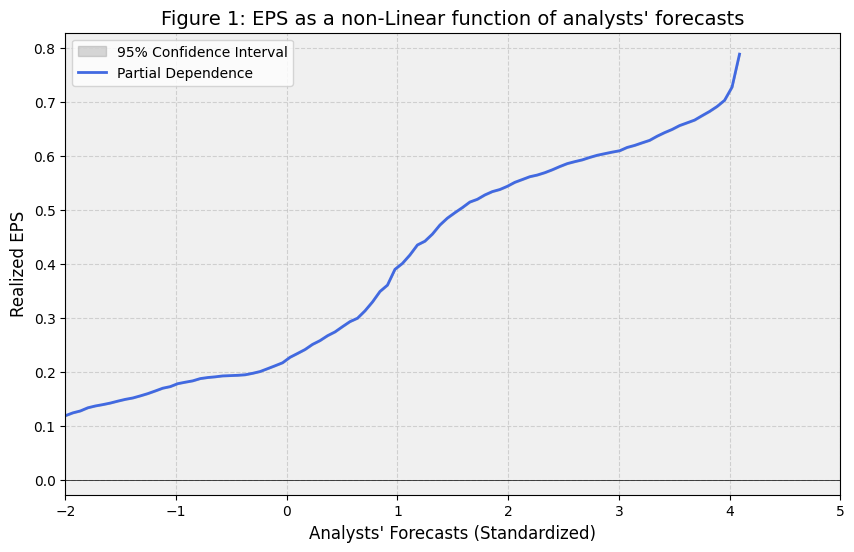

In [4]:
# ==========================================
# 3. 绘制 Partial Dependence Plot (复现风格)
# ==========================================

print("Calculating Partial Dependence...")

calc_percentiles = (0, 1)

# 计算 PDP
pdp_results = partial_dependence(
    rf_model,
    X_scaled,
    [meanest_idx],
    kind='average',
    grid_resolution=100,
    percentiles=calc_percentiles
)

# 获取 X轴 (特征值) 和 Y轴 (预测值)
x_vals = pdp_results['grid_values'][0]
y_vals = pdp_results['average'][0]

# 计算 ICE 用于置信区间
ice_results = partial_dependence(
    rf_model,
    X_scaled,
    [meanest_idx],
    kind='individual',
    grid_resolution=100,
    percentiles=calc_percentiles
)
ice_lines = ice_results['individual'][0]

# 95% 置信区间: Mean +/- 1.96 * SEM
n_samples = ice_lines.shape[0]
std_dev = np.std(ice_lines, axis=0)
sem = std_dev / np.sqrt(n_samples)
margin_of_error = 1.96 * sem
upper = y_vals + margin_of_error
lower = y_vals - margin_of_error

# --- 绘图 ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(x_vals, lower, upper, color='grey', alpha=0.3, label='95% Confidence Interval')
ax.plot(x_vals, y_vals, color='royalblue', linewidth=2, label='Partial Dependence')
ax.axhline(0, color='black', linewidth=0.5)

ax.set_xlim(-2, 5)
ax.set_title("Figure 1: EPS as a non-Linear function of analysts' forecasts", fontsize=14)
ax.set_xlabel("Analysts' Forecasts (Standardized)", fontsize=12)
ax.set_ylabel("Realized EPS", fontsize=12)
ax.legend(loc='upper left')

ax.grid(True, linestyle='--', alpha=0.5)
ax.set_facecolor('#f0f0f0')

plt.show()